In [1]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

print("scikit-fuzzy is ready!")

scikit-fuzzy is ready!


In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [3]:
optimized_xgb = joblib.load(
    "models/optimized_xgboost.pkl"
)

model_config = joblib.load(
    "models/model_config.pkl"
)

print("Model loaded successfully.")
print("Optimized threshold:", model_config["threshold"])

Model loaded successfully.
Optimized threshold: 0.9500000000000001


In [4]:
df["Log_Amount"] = np.log1p(df["Amount"])

df["Hour"] = (
    (df["Time"] / 3600) % 24
)
features = [
    col for col in df.columns
    if col != "Class"
]

X = df[features]

print("Number of features:", X.shape[1])

Number of features: 32


In [5]:
fraud_probability = optimized_xgb.predict_proba(X)[:, 1]

df["Fraud_Probability"] = fraud_probability

df[[
    "Amount",
    "Fraud_Probability",
    "Class"
]].head()

,Amount,Fraud_Probability,Class
0,149.62,1.893145e-05,0
1,2.69,7.013873e-05,0
2,378.66,1.807890e-05,0
3,123.50,3.058830e-07,0
4,69.99,2.024412e-06,0


In [6]:
df["Amount_Risk"] = (
    df["Amount"]
    .rank(pct=True) * 100
)

In [7]:
df[[
    "Amount",
    "Amount_Risk"
]].head()

,Amount,Amount_Risk
0,149.62,85.933106
1,2.69,18.517277
2,378.66,95.210090
3,123.50,83.229871
4,69.99,73.113547


In [8]:
v_features = [
    f"V{i}" for i in range(1, 29)
]


In [9]:
from sklearn.preprocessing import StandardScaler

legitimate_data = df.loc[
    df["Class"] == 0,
    v_features
]

scaler = StandardScaler()

legitimate_scaled = scaler.fit_transform(
    legitimate_data
)
legitimate_centroid = legitimate_scaled.mean(axis=0)
all_scaled = scaler.transform(
    df[v_features]
)
anomaly_distance = np.sqrt(
    ((all_scaled - legitimate_centroid) ** 2).sum(axis=1)
)

df["Anomaly_Distance"] = anomaly_distance
df["Anomaly_Distance"].describe()


count    284807.000000
mean          4.703249
std           2.668303
min           2.113202
25%           3.471624
50%           4.230400
75%           5.182028
max         196.703909
Name: Anomaly_Distance, dtype: float64

In [10]:
df["Anomaly_Score"] = (
    df["Anomaly_Distance"]
    .rank(pct=True) * 100
)
df[[
    "Fraud_Probability",
    "Amount_Risk",
    "Anomaly_Score",
    "Class"
]].head()

,Fraud_Probability,Amount_Risk,Anomaly_Score,Class
0,1.893145e-05,85.933106,17.809604,0
1,7.013873e-05,18.517277,2.593335,0
2,1.807890e-05,95.210090,91.027257,0
3,3.058830e-07,83.229871,62.868188,0
4,2.024412e-06,73.113547,27.949102,0


In [11]:
fraud_prob = ctrl.Antecedent(
    np.arange(0, 101, 1),
    "fraud_probability"
)

amount_risk = ctrl.Antecedent(
    np.arange(0, 101, 1),
    "amount_risk"
)

anomaly_score = ctrl.Antecedent(
    np.arange(0, 101, 1),
    "anomaly_score"
)

risk = ctrl.Consequent(
    np.arange(0, 101, 1),
    "risk"
)

In [12]:
fraud_prob["low"] = fuzz.trapmf(
    fraud_prob.universe,
    [0, 0, 20, 40]
)

fraud_prob["medium"] = fuzz.trimf(
    fraud_prob.universe,
    [25, 50, 75]
)

fraud_prob["high"] = fuzz.trapmf(
    fraud_prob.universe,
    [60, 80, 100, 100]
)

In [13]:
amount_risk["low"] = fuzz.trapmf(
    amount_risk.universe,
    [0, 0, 20, 40]
)

amount_risk["medium"] = fuzz.trimf(
    amount_risk.universe,
    [25, 50, 75]
)

amount_risk["high"] = fuzz.trapmf(
    amount_risk.universe,
    [60, 80, 100, 100]
)

In [14]:
anomaly_score["low"] = fuzz.trapmf(
    anomaly_score.universe,
    [0, 0, 20, 40]
)

anomaly_score["medium"] = fuzz.trimf(
    anomaly_score.universe,
    [25, 50, 75]
)

anomaly_score["high"] = fuzz.trapmf(
    anomaly_score.universe,
    [60, 80, 100, 100]
)

In [15]:
risk["low"] = fuzz.trapmf(
    risk.universe,
    [0, 0, 20, 40]
)

risk["medium"] = fuzz.trimf(
    risk.universe,
    [30, 50, 70]
)

risk["high"] = fuzz.trapmf(
    risk.universe,
    [60, 80, 100, 100]
)

c:\Users\Darsh maru\AppData\Local\Programs\Python\Python313\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


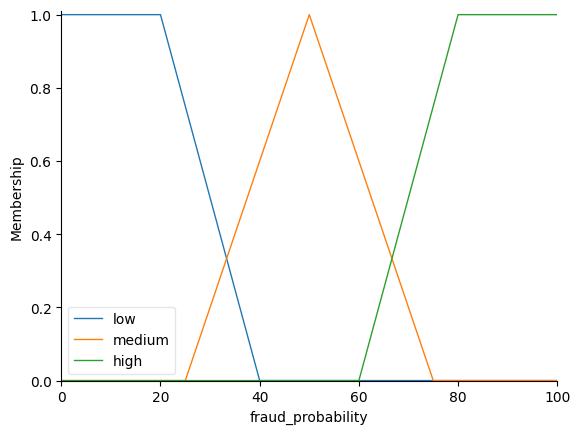

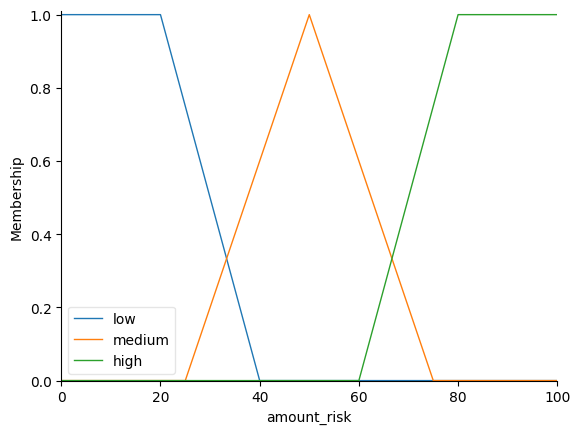

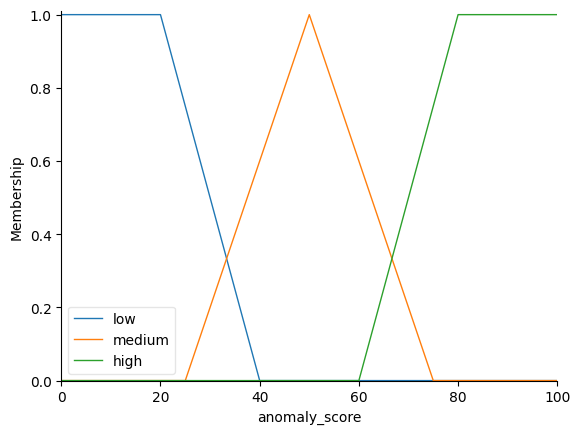

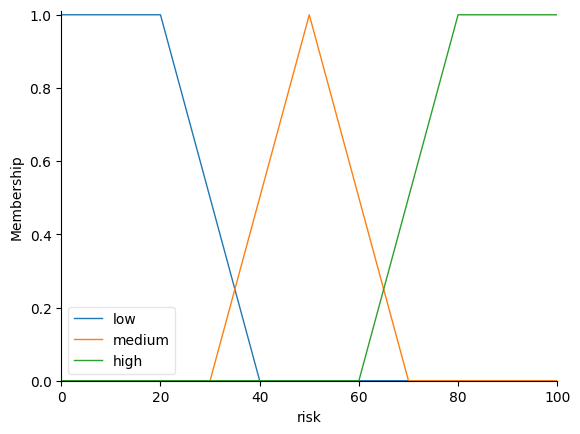

In [16]:
fraud_prob.view()
amount_risk.view()
anomaly_score.view()
risk.view()

In [56]:
# ==============================
# FUZZY RISK RULES
# ==============================

# LOW RISK
rule1 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["low"] &
    anomaly_score["low"],
    risk["low"]
)

rule2 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["medium"] &
    anomaly_score["low"],
    risk["low"]
)

rule3 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["low"] &
    anomaly_score["medium"],
    risk["medium"]
)


# MEDIUM RISK
rule4 = ctrl.Rule(
    fraud_prob["medium"] &
    amount_risk["low"] &
    anomaly_score["low"],
    risk["medium"]
)

rule5 = ctrl.Rule(
    fraud_prob["medium"] &
    amount_risk["medium"] &
    anomaly_score["low"],
    risk["medium"]
)

rule6 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["high"] &
    anomaly_score["low"],
    risk["medium"]
)

rule7 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["medium"] &
    anomaly_score["medium"],
    risk["medium"]
)

rule8 = ctrl.Rule(
    fraud_prob["medium"] &
    amount_risk["low"] &
    anomaly_score["medium"],
    risk["medium"]
)


# HIGH RISK
rule9 = ctrl.Rule(
    fraud_prob["high"],
    risk["high"]
)

rule10 = ctrl.Rule(
    fraud_prob["medium"] &
    anomaly_score["high"],
    risk["high"]
)

rule11 = ctrl.Rule(
    fraud_prob["medium"] &
    amount_risk["high"],
    risk["high"]
)

rule12 = ctrl.Rule(
    amount_risk["high"] &
    anomaly_score["high"],
    risk["high"]
)

rule13 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["high"] &
    anomaly_score["medium"],
    risk["high"]
)

rule14 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["medium"] &
    anomaly_score["high"],
    risk["high"]
)

rule15 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["high"] &
    anomaly_score["high"],
    risk["high"]
)

In [57]:
risk_control = ctrl.ControlSystem([
    rule1,
    rule2,
    rule3,
    rule4,
    rule5,
    rule6,
    rule7,
    rule8,
    rule9,
    rule10,
    rule11,
    rule12,
    rule13,
    rule14,
    rule15
])

print("Fuzzy control system recreated successfully.")

Fuzzy control system recreated successfully.


In [58]:
risk_simulation = ctrl.ControlSystemSimulation(
    risk_control
)

print("Fuzzy simulation ready.")

Fuzzy simulation ready.


In [59]:
def calculate_fuzzy_risk(
    fraud_probability,
    amount_risk,
    anomaly_score
):
    
    simulation = ctrl.ControlSystemSimulation(
        risk_control
    )
    
    simulation.input["fraud_probability"] = (
        fraud_probability * 100
    )
    
    simulation.input["amount_risk"] = amount_risk
    
    simulation.input["anomaly_score"] = anomaly_score
    
    try:
        simulation.compute()
        
        risk_score = simulation.output["risk"]
        
    except (KeyError, ValueError):
        # Safety fallback if no fuzzy rule fires
        risk_score = (
            0.60 * fraud_probability * 100
            + 0.20 * amount_risk
            + 0.20 * anomaly_score
        )
        
        risk_score = np.clip(
            risk_score,
            0,
            100
        )
    
    if risk_score < 30:
        risk_level = "LOW"
    elif risk_score < 70:
        risk_level = "MEDIUM"
    else:
        risk_level = "HIGH"
    
    return risk_score, risk_level

In [52]:
score, level = calculate_fuzzy_risk(
    sample["Fraud_Probability"],
    sample["Amount_Risk"],
    sample["Anomaly_Score"]
)

print("Risk Score:", round(score, 2))
print("Risk Level:", level)

Risk Score: 50.0
Risk Level: MEDIUM


In [54]:
high_fraud = df.loc[
    df["Fraud_Probability"].idxmax()
]

print(
    high_fraud[
        [
            "Amount",
            "Fraud_Probability",
            "Amount_Risk",
            "Anomaly_Score",
            "Class"
        ]
    ]
)

score, level = calculate_fuzzy_risk(
    high_fraud["Fraud_Probability"],
    high_fraud["Amount_Risk"],
    high_fraud["Anomaly_Score"]
)

print("\nFuzzy Risk Score:", round(score, 2))
print("Risk Level:", level)

Amount               172.320000
Fraud_Probability      1.000000
Amount_Risk           87.998890
Anomaly_Score         99.667143
Class                  1.000000
Name: 43773, dtype: float64

Fuzzy Risk Score: 84.44
Risk Level: HIGH


In [60]:
risk_scores = []
risk_levels = []

for _, row in risk_test_df.iterrows():

    score, level = calculate_fuzzy_risk(
        row["Fraud_Probability"],
        row["Amount_Risk"],
        row["Anomaly_Score"]
    )

    risk_scores.append(score)
    risk_levels.append(level)

risk_test_df["Fuzzy_Risk_Score"] = risk_scores
risk_test_df["Risk_Level"] = risk_levels

print("Fuzzy risk assessment completed.")

Fuzzy risk assessment completed.


In [61]:
risk_distribution = pd.crosstab(
    risk_test_df["Risk_Level"],
    risk_test_df["Class"],
    normalize="columns"
) * 100

risk_distribution
risk_test_df.groupby("Class")["Fuzzy_Risk_Score"].mean()

Class
0    49.912542
1    83.435486
Name: Fuzzy_Risk_Score, dtype: float64

In [62]:
risk_distribution = pd.crosstab(
    risk_test_df["Risk_Level"],
    risk_test_df["Class"],
    normalize="columns"
) * 100

print(risk_distribution)

Class          0          1
Risk_Level                 
HIGH        32.0  98.170732
LOW         33.0   1.016260
MEDIUM      35.0   0.813008


In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

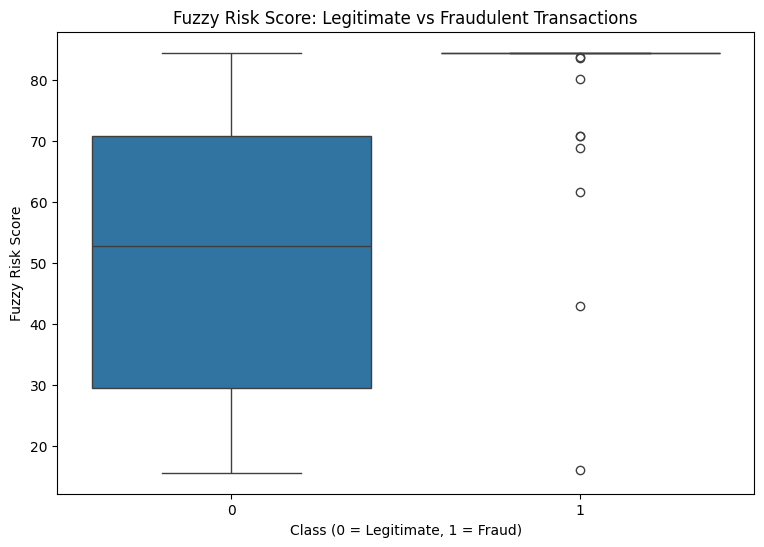

In [44]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=risk_test_df,
    x="Class",
    y="Fuzzy_Risk_Score"
)

plt.title(
    "Fuzzy Risk Score: Legitimate vs Fraudulent Transactions"
)

plt.xlabel(
    "Class (0 = Legitimate, 1 = Fraud)"
)

plt.ylabel("Fuzzy Risk Score")

plt.show()

<Figure size 900x600 with 0 Axes>

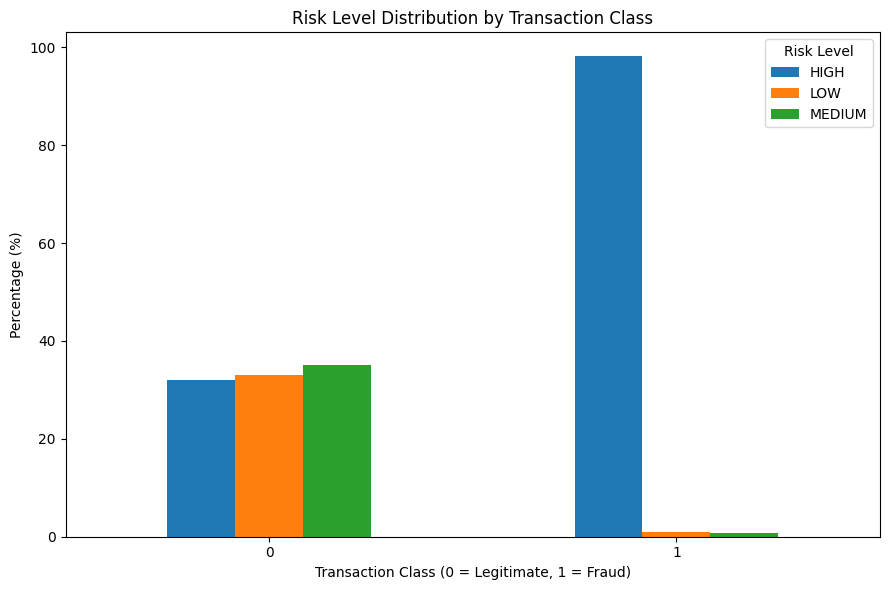

In [64]:
plt.figure(figsize=(9, 6))

risk_distribution.T.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title(
    "Risk Level Distribution by Transaction Class"
)

plt.xlabel(
    "Transaction Class (0 = Legitimate, 1 = Fraud)"
)

plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(title="Risk Level")

plt.tight_layout()

plt.show()

In [65]:
risk_test_df.groupby("Class")["Fuzzy_Risk_Score"].mean()
risk_distribution

Class,0,1
Risk_Level,,
HIGH,32.0,98.170732
LOW,33.0,1.016260
MEDIUM,35.0,0.813008


In [66]:
risk_counts = pd.crosstab(
    risk_test_df["Risk_Level"],
    risk_test_df["Class"]
)

risk_counts

Class,0,1
Risk_Level,,
HIGH,160,483
LOW,165,5
MEDIUM,175,4


In [48]:
high_risk = risk_test_df[
    risk_test_df["Risk_Level"] == "HIGH"
]

high_risk_precision = (
    (high_risk["Class"] == 1).sum()
    / len(high_risk)
)

print(
    "HIGH-risk precision:",
    round(high_risk_precision * 100, 2),
    "%"
)
fraud_transactions = risk_test_df[
    risk_test_df["Class"] == 1
]

high_risk_fraud_capture = (
    (fraud_transactions["Risk_Level"] == "HIGH").sum()
    / len(fraud_transactions)
)

print(
    "Fraud transactions classified HIGH risk:",
    round(high_risk_fraud_capture * 100, 2),
    "%"
)

HIGH-risk precision: 76.85 %
Fraud transactions classified HIGH risk: 99.19 %
